# Week 6 Student Worksheet: Spatial Prediction Shootout

## Traditional Stats vs. Machine Learning: Filling the Gaps

> *"Kriging tells you where it's uncertain. ML just says 'trust me.'"*

### Today's Mission

Transform Week 5's discrete rainfall stations into **continuous rainfall surfaces** using **two fundamentally different approaches**:

1. **Kriging (Statistical)** — uses spatial correlation + provides uncertainty
2. **Random Forest (ML)** — uses data patterns + easily adds features

Then compare them head-to-head with two simpler methods (Nearest Neighbor, IDW) and determine which gives the Commander more actionable intelligence.

> Fill in the code cells marked with `# YOUR CODE HERE`. Use AI tools strategically — but understand every line you write.

In [ ]:
# Install required packages (run once)
%pip install pykrige scikit-learn rasterio rasterstats --quiet

---

## Cell [1]: Environment Setup & Data Loading (Slide 2)

Load the Fung-wong typhoon data and filter to the study area. Reuse your Week 5 `parse_rainfall_json()` function.

**AI Prompt Suggestion**:
```
I need to load fungwong_202511.json and parse it into a GeoDataFrame using
my Week 5 parse_rainfall_json() function. Then filter to 花蓮縣 and 宜蘭縣,
remove -998/zero rain stations, and convert to EPSG:3826.
Show me the top 5 stations by rain_1hr.
```

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
from shapely.geometry import Point
warnings.filterwarnings('ignore')

# =========================
# 1. Helper functions
# =========================
def safe_float(x):
    try:
        if x in [None, "", "-998", -998]:
            return None
        return float(x)
    except:
        return None


def normalize_cwa_json(raw_json):
    """
    Normalize both:
    1. Week5 simulated CWA-like JSON
    2. Live CWA-style JSON (if structure is similar)

    Output columns:
    - station_name
    - station_id
    - county
    - lat
    - lon
    - rain_1hr
    """
    stations = raw_json.get("records", {}).get("Station", [])
    rows = []

    for st in stations:
        station_name = st.get("StationName", "")
        station_id = st.get("StationId", "")

        # ---- county (try several possible locations) ----
        county = (
            st.get("CountyName")
            or st.get("GeoInfo", {}).get("CountyName")
            or st.get("GeoInfo", {}).get("Address", "")
            or ""
        )

        # ---- coordinates ----
        lat, lon = None, None
        coords = st.get("GeoInfo", {}).get("Coordinates", [])

        if isinstance(coords, list) and len(coords) > 0:
            # Prefer WGS84 if multiple coordinate sets exist
            chosen = None
            for c in coords:
                coord_name = str(c.get("CoordinateName", "")).upper()
                if "WGS84" in coord_name:
                    chosen = c
                    break
            if chosen is None:
                chosen = coords[0]

            lat = safe_float(chosen.get("StationLatitude"))
            lon = safe_float(chosen.get("StationLongitude"))

        # ---- rainfall ----
        rain_1hr = None
        rainfall = st.get("RainfallElement", {})

        if "Past1hr" in rainfall and isinstance(rainfall["Past1hr"], dict):
            rain_1hr = safe_float(rainfall["Past1hr"].get("Precipitation"))

        if rain_1hr is None and "Now" in rainfall and isinstance(rainfall["Now"], dict):
            rain_1hr = safe_float(rainfall["Now"].get("Precipitation"))

        if rain_1hr is None:
            for _, v in rainfall.items():
                if isinstance(v, dict) and "Precipitation" in v:
                    rain_1hr = safe_float(v.get("Precipitation"))
                    if rain_1hr is not None:
                        break

        rows.append({
            "station_name": station_name,
            "station_id": station_id,
            "county": county,
            "lat": lat,
            "lon": lon,
            "rain_1hr": rain_1hr
        })

    return pd.DataFrame(rows)


def parse_rainfall_json(json_path):
    """
    Read JSON -> normalize -> clean -> GeoDataFrame (EPSG:4326)
    """
    with open(json_path, "r", encoding="utf-8") as f:
        raw_json = json.load(f)

    rain_df = normalize_cwa_json(raw_json)

    # remove missing coords / rainfall
    rain_df = rain_df.dropna(subset=["lat", "lon", "rain_1hr"]).copy()

    # remove invalid rainfall
    rain_df = rain_df[rain_df["rain_1hr"] > 0].copy()

    # to GeoDataFrame
    rain_gdf = gpd.GeoDataFrame(
        rain_df,
        geometry=gpd.points_from_xy(rain_df["lon"], rain_df["lat"]),
        crs="EPSG:4326"
    )

    return rain_gdf


# =========================
# 2. Load rainfall scenario
# =========================
rain_gdf = parse_rainfall_json("data/scenarios/fungwong_202511.json")

# =========================
# 3. Filter study area: 宜蘭縣 + 花蓮縣
# =========================
study_rain = rain_gdf[
    rain_gdf["county"].astype(str).str.contains("宜蘭|花蓮", na=False)
].copy()

# 如果 county 欄位抓不到，可用座標範圍作備援
if len(study_rain) == 0:
    study_rain = rain_gdf[
        (rain_gdf.geometry.y >= 23.3) & (rain_gdf.geometry.y <= 25.5) &
        (rain_gdf.geometry.x >= 121.0) & (rain_gdf.geometry.x <= 122.2)
    ].copy()

# =========================
# 4. Convert to EPSG:3826
# =========================
study_rain_3826 = study_rain.to_crs(epsg=3826)

# =========================
# 5. Extract coordinate arrays for Kriging / ML
# =========================
x = study_rain_3826.geometry.x.values   # Easting (meters)
y = study_rain_3826.geometry.y.values   # Northing (meters)
z = study_rain_3826["rain_1hr"].values  # rainfall

print(f"Study area stations (rain > 0): {len(study_rain_3826)}")
print(f"CRS: {study_rain_3826.crs}")
print("\nTop 5 stations:")
print(
    study_rain_3826.nlargest(5, "rain_1hr")[["station_name", "county", "rain_1hr"]]
    .to_string(index=False)
)

# YOUR CODE HERE:
# 1. Define normalize_cwa_json() and parse_rainfall_json() (copy from Week 5)
# 2. Load 'data/scenarios/fungwong_202511.json'
# 3. Parse into GeoDataFrame
# 4. Filter to 花蓮縣 + 宜蘭縣
# 5. Remove stations with rain_1hr <= 0
# 6. Convert to EPSG:3826


# Extract coordinate arrays for Kriging / ML
# x = study_rain_3826.geometry.x.values  # Easting (meters)
# y = study_rain_3826.geometry.y.values  # Northing (meters)
# z = study_rain_3826['rain_1hr'].values

# print(f"Study area stations (rain > 0): {len(study_rain_3826)}")
# print(f"CRS: {study_rain_3826.crs}")
# print(f"\nTop 5 stations:")
# print(study_rain_3826.nlargest(5, 'rain_1hr')[['station_name', 'county', 'rain_1hr']].to_string(index=False))

Study area stations (rain > 0): 89
CRS: EPSG:3826

Top 5 stations:
station_name county  rain_1hr
          蘇澳    宜蘭縣     130.5
     國五S047K    宜蘭縣      80.5
          五結    宜蘭縣      71.0
          冬山    宜蘭縣      61.5
     國五S041K    宜蘭縣      46.0


---

## Cell [2a]: Variogram — First Attempt (Naive)

Try running Kriging directly on the raw rainfall data. **Don't worry if it looks bad — that's the point.**

**Key Concepts** (will make sense after you see the result):
- **Nugget**: How noisy is each measurement?
- **Sill**: What's the maximum difference between stations?
- **Range**: How far apart do stations need to be before they stop "knowing about each other"?

**CRS Warning**: The x, y arrays MUST be in EPSG:3826 (meters). Using lat/lon will give wrong results.

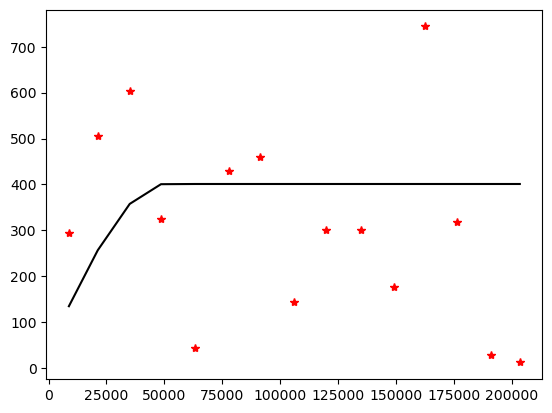

Sill:   360.8
Range:  50000 m (50.0 km)
Nugget: 40.1

⚠️ Look at the plot — do the dots follow the curve?


In [2]:
from pykrige.ok import OrdinaryKriging

# 🔴 First attempt: run Kriging on raw rainfall data

# 1. Initial parameters
initial_sill = float(z.var())
initial_range = 50000.0   # 50 km
initial_nugget = float(z.var() * 0.1)

# 2. Create OrdinaryKriging on raw rainfall
OK_naive = OrdinaryKriging(
    x, y, z,
    variogram_model='spherical',
    verbose=False,
    enable_plotting=True,
    nlags=15,
    variogram_parameters={
        'sill': initial_sill,
        'range': initial_range,
        'nugget': initial_nugget
    }
)

# 3. Print fitted variogram parameters
params = OK_naive.variogram_model_parameters
print(f"Sill:   {params[0]:.1f}")
print(f"Range:  {params[1]:.0f} m ({params[1]/1000:.1f} km)")
print(f"Nugget: {params[2]:.1f}")
print("\n⚠️ Look at the plot — do the dots follow the curve?")

## Cell [2b]: Why Did It Fail? — Look at the Histogram

The variogram looked bad. Before blaming the tool, **look at your data**.

Plot a histogram of the rainfall values. What do you see?

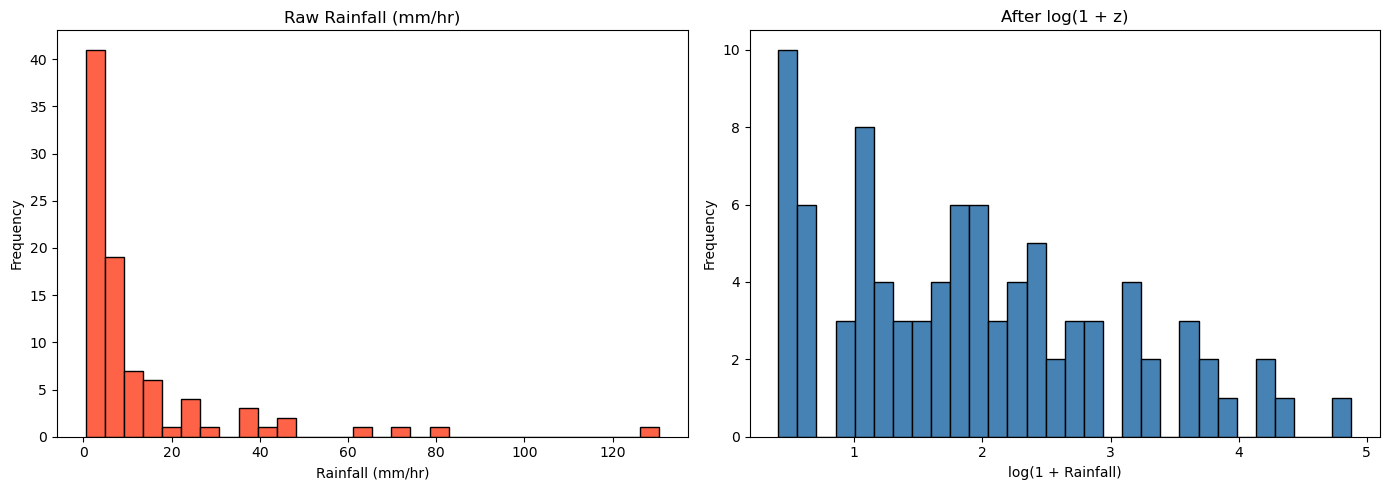

Left: most stations have low rainfall, but a few stations have very high values.
These extreme values distort the variogram.
Right: after log-transform, the distribution becomes more balanced.


In [3]:
# =========================
# Histogram comparison
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Raw rainfall
axes[0].hist(z, bins=30, color='tomato', edgecolor='black')
axes[0].set_title('Raw Rainfall (mm/hr)')
axes[0].set_xlabel('Rainfall (mm/hr)')
axes[0].set_ylabel('Frequency')

# 2. Log-transformed rainfall
z_log = np.log1p(z)

axes[1].hist(z_log, bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('After log(1 + z)')
axes[1].set_xlabel('log(1 + Rainfall)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Left: most stations have low rainfall, but a few stations have very high values.")
print("These extreme values distort the variogram.")
print("Right: after log-transform, the distribution becomes more balanced.")

## Cell [2c]: Variogram — Second Attempt (with Log-Transform)

Now redo the variogram using the log-transformed data. Compare this plot with Cell [2a] — it should be much better.

**Rule of thumb**: If your histogram has a long tail to the right, apply `np.log1p(z)` before Kriging, then use `np.expm1()` to convert back after prediction.

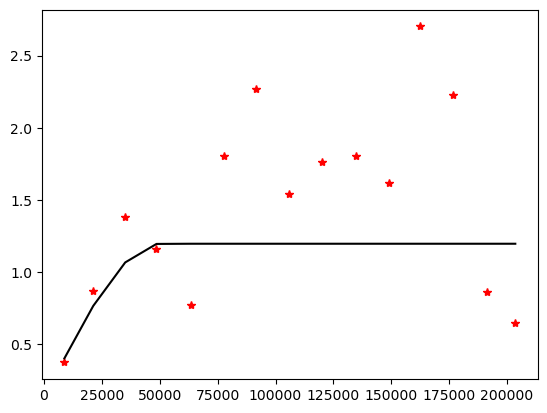

Sill:   1.076
Range:  50000 m (50.0 km)
Nugget: 0.120

✅ Compare with Cell [2a] — the dots should follow the curve now.


In [4]:
# 🟢 Second attempt: Kriging on log-transformed data

# 1. log-transform rainfall
z_log = np.log1p(z)

# 2. Initial parameters based on log-transformed variance
initial_sill = float(z_log.var())
initial_range = 50000.0
initial_nugget = float(z_log.var() * 0.1)

# 3. Create OrdinaryKriging using z_log
OK = OrdinaryKriging(
    x, y, z_log,
    variogram_model='spherical',
    verbose=False,
    enable_plotting=True,
    nlags=15,
    variogram_parameters={
        'sill': initial_sill,
        'range': initial_range,
        'nugget': initial_nugget
    }
)

# 4. Show fitted parameters
params = OK.variogram_model_parameters
print(f"Sill:   {params[0]:.3f}")
print(f"Range:  {params[1]:.0f} m ({params[1]/1000:.1f} km)")
print(f"Nugget: {params[2]:.3f}")
print("\n✅ Compare with Cell [2a] — the dots should follow the curve now.")

## Cell [2d]: Which Variogram Fits Best? — Range & Model Comparison (Slide 7)

Compare variograms **one variable at a time** — this is how scientists isolate effects:

- **Figure 1**: Fix model = **Spherical**, vary Range (50km, 25km, 15km) → what does Range do?
- **Figure 2**: Fix model = **Exponential**, vary Range (50km, 25km, 15km) → same exercise
- **Then compare**: same Range, different model → what does the model choice do?

**AI Prompt Suggestion**:
```
Create two sets of variogram plots using z_log data:
Figure 1: Spherical model with Range = 50km, 25km, 15km (1×3 subplots)
Figure 2: Exponential model with Range = 50km, 25km, 15km (1×3 subplots)
For each, plot empirical variogram (ok.lags vs ok.semivariance) as red dots
and the fitted model curve as a black line.
Compute SSE for each config and print a summary table.
Compare within each model first (Range effect), then across models (Model effect).
```

In [5]:
# YOUR CODE HERE:
# 1. Define ranges: [50000, 25000, 15000]
# 2. Figure 1: Spherical × 3 Ranges (1×3 subplot)
#    For each: create OrdinaryKriging, plot lags vs semivariance (red dots),
#    plot fitted curve (black line), compute SSE
# 3. Figure 2: Exponential × 3 Ranges (1×3 subplot)
#    Same as above but with variogram_model='exponential'
# 4. Print summary table:
#    - Compare within Spherical (Range effect)
#    - Compare within Exponential (Range effect)
#    - Compare Spherical vs Exponential at same Range (Model effect)

# ranges_km = [50, 25, 15]

# ─── Figure 1: Spherical ───
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# for ax, rkm in zip(axes, ranges_km):
#     ok_test = OrdinaryKriging(x, y, z_log, variogram_model='spherical', ...)
#     ax.scatter(ok_test.lags/1000, ok_test.semivariance, c='red', ...)
#     # plot fitted curve ...

# ─── Figure 2: Exponential ───
# (same structure)

# 💡 Questions:
#   1. Within Spherical, which Range gives the best fit?
#   2. Within Exponential, which Range gives the best fit?
#   3. At the same Range, does model choice matter much?

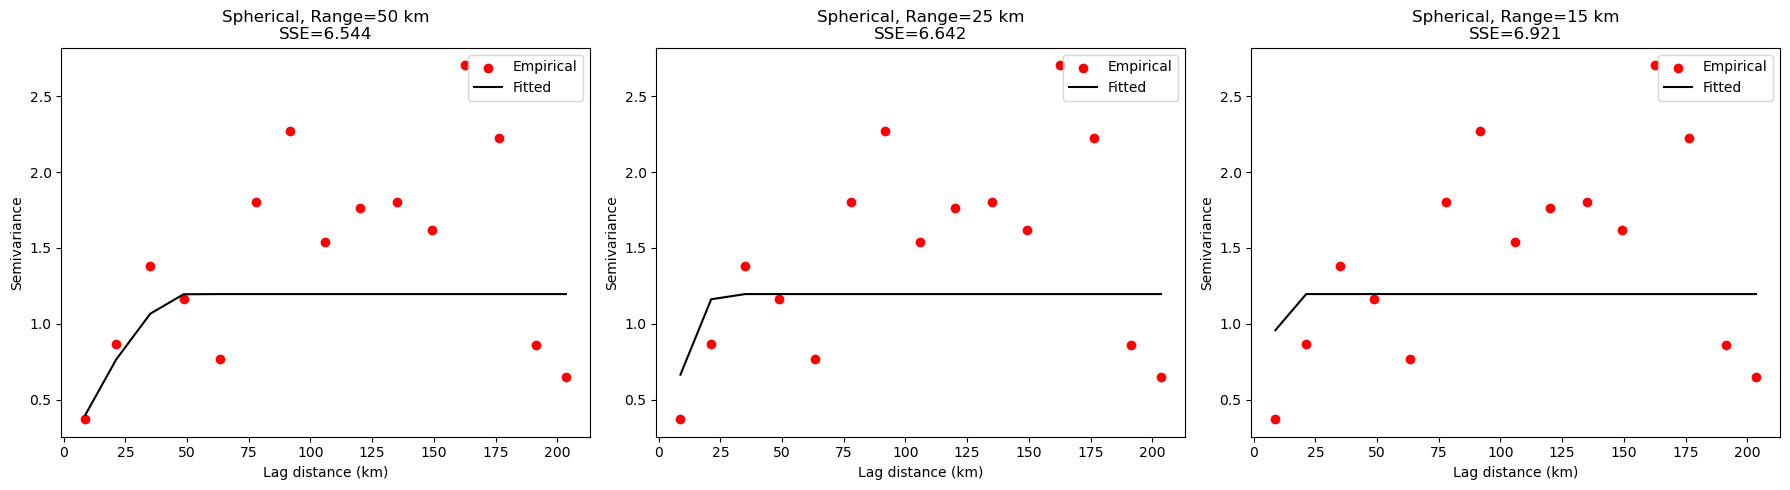

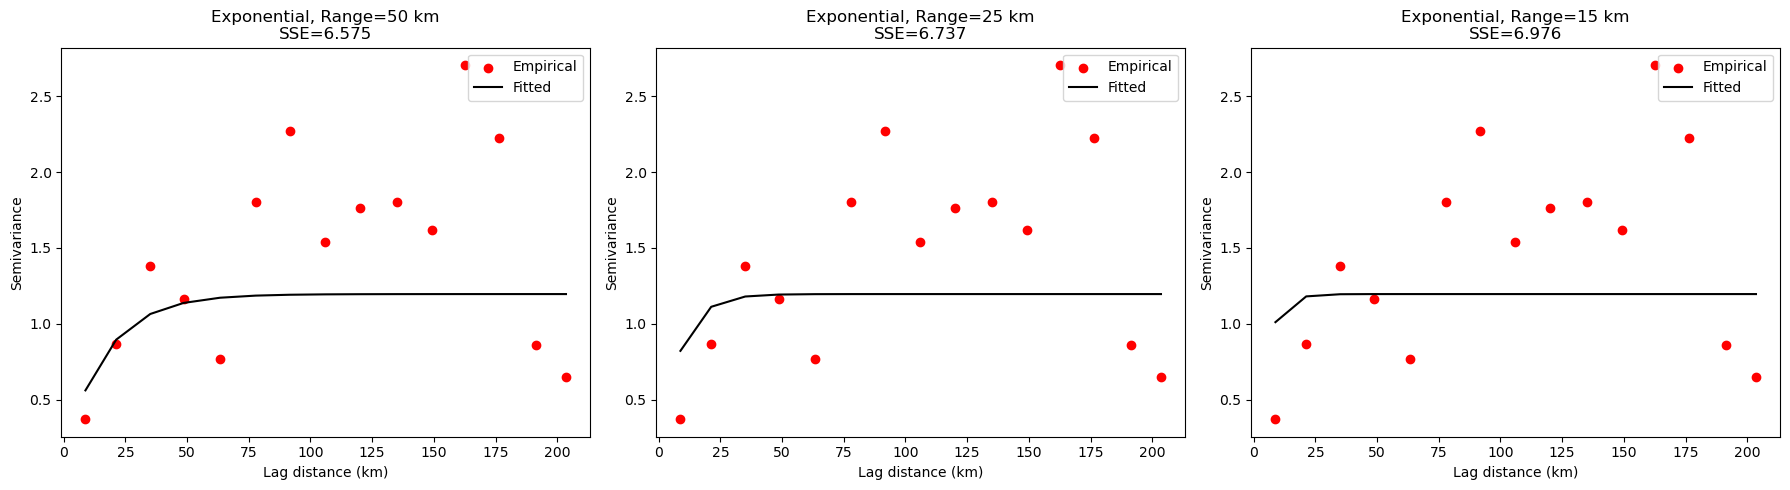

=== SSE Summary ===
      model  range_km      sse
exponential        50 6.575366
exponential        25 6.737273
exponential        15 6.976205
  spherical        50 6.544171
  spherical        25 6.642205
  spherical        15 6.921389

=== Within Spherical ===
    model  range_km      sse
spherical        50 6.544171
spherical        25 6.642205
spherical        15 6.921389

=== Within Exponential ===
      model  range_km      sse
exponential        50 6.575366
exponential        25 6.737273
exponential        15 6.976205

=== Compare same range across models ===
Range = 50 km  -> best: spherical   (SSE=6.544)
Range = 25 km  -> best: spherical   (SSE=6.642)
Range = 15 km  -> best: spherical   (SSE=6.921)


In [6]:
# =========================
# Variogram comparison: range + model
# =========================

ranges_km = [50, 25, 15]
results = []

def calc_sse(ok_obj):
    """
    SSE between empirical semivariance points and fitted variogram curve
    """
    lags = np.array(ok_obj.lags)
    empirical = np.array(ok_obj.semivariance)
    fitted = ok_obj.variogram_function(ok_obj.variogram_model_parameters, lags)
    sse = np.sum((empirical - fitted) ** 2)
    return fitted, sse


# ─── Figure 1: Spherical ───
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, rkm in zip(axes, ranges_km):
    sill = float(z_log.var())
    nugget = float(z_log.var() * 0.1)
    vrange = float(rkm * 1000)

    ok_test = OrdinaryKriging(
        x, y, z_log,
        variogram_model='spherical',
        verbose=False,
        enable_plotting=False,
        nlags=15,
        variogram_parameters={
            'sill': sill,
            'range': vrange,
            'nugget': nugget
        }
    )

    fitted, sse = calc_sse(ok_test)

    ax.scatter(ok_test.lags / 1000, ok_test.semivariance, c='red', label='Empirical')
    ax.plot(ok_test.lags / 1000, fitted, c='black', label='Fitted')
    ax.set_title(f'Spherical, Range={rkm} km\nSSE={sse:.3f}')
    ax.set_xlabel('Lag distance (km)')
    ax.set_ylabel('Semivariance')
    ax.legend()

    results.append({
        'model': 'spherical',
        'range_km': rkm,
        'sse': sse
    })

plt.tight_layout()
plt.show()


# ─── Figure 2: Exponential ───
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, rkm in zip(axes, ranges_km):
    sill = float(z_log.var())
    nugget = float(z_log.var() * 0.1)
    vrange = float(rkm * 1000)

    ok_test = OrdinaryKriging(
        x, y, z_log,
        variogram_model='exponential',
        verbose=False,
        enable_plotting=False,
        nlags=15,
        variogram_parameters={
            'sill': sill,
            'range': vrange,
            'nugget': nugget
        }
    )

    fitted, sse = calc_sse(ok_test)

    ax.scatter(ok_test.lags / 1000, ok_test.semivariance, c='red', label='Empirical')
    ax.plot(ok_test.lags / 1000, fitted, c='black', label='Fitted')
    ax.set_title(f'Exponential, Range={rkm} km\nSSE={sse:.3f}')
    ax.set_xlabel('Lag distance (km)')
    ax.set_ylabel('Semivariance')
    ax.legend()

    results.append({
        'model': 'exponential',
        'range_km': rkm,
        'sse': sse
    })

plt.tight_layout()
plt.show()


# ─── Summary table ───
results_df = pd.DataFrame(results).sort_values(['model', 'sse']).reset_index(drop=True)
print("=== SSE Summary ===")
print(results_df.to_string(index=False))

print("\n=== Within Spherical ===")
print(
    results_df[results_df['model'] == 'spherical']
    .sort_values('sse')
    .to_string(index=False)
)

print("\n=== Within Exponential ===")
print(
    results_df[results_df['model'] == 'exponential']
    .sort_values('sse')
    .to_string(index=False)
)

print("\n=== Compare same range across models ===")
for rkm in ranges_km:
    sub = results_df[results_df['range_km'] == rkm].sort_values('sse')
    best_model = sub.iloc[0]['model']
    best_sse = sub.iloc[0]['sse']
    print(f"Range = {rkm:>2} km  -> best: {best_model:<11} (SSE={best_sse:.3f})")

## Cell [3]: Define the Interpolation Grid & Run Kriging (Slide 8)

Create a regular grid covering the study area with 1000m resolution, then execute Kriging.

**Think about**:
- What units is the grid in? (Hint: same as your CRS = meters)
- Why add a buffer around the station extent?

**Important**: Kriging runs in log-space. After prediction, **back-transform** with `np.expm1()` to get rainfall in mm/hr.

In [ ]:
import time

# YOUR CODE HERE:
# 1. Calculate grid extent from x, y arrays (with 5km buffer)
# 2. Create grid_x and grid_y using np.arange with 1000m step
# 3. Execute Kriging in log-space: z_kriging_log, ss_kriging_log = OK.execute('grid', grid_x, grid_y)
# 4. Back-transform: z_kriging = np.expm1(z_kriging_log)

buffer_m = 5000
resolution = 1000  # meters — use 500 for finer resolution (slower)

# x_min = x.min() - buffer_m
# x_max = x.max() + buffer_m
# y_min = y.min() - buffer_m
# y_max = y.max() + buffer_m
# grid_x = np.arange(x_min, x_max, resolution)
# grid_y = np.arange(y_min, y_max, resolution)

# print(f"Grid: {len(grid_x)}×{len(grid_y)} = {len(grid_x)*len(grid_y):,} points @ {resolution}m")

# t0 = time.time()
# z_kriging_log, ss_kriging_log = OK.execute('grid', grid_x, grid_y)
# print(f"✓ Kriging (log-space) done in {time.time()-t0:.1f}s")

# # Back-transform to real rainfall (mm/hr)
# z_kriging = np.expm1(z_kriging_log)
# z_kriging[z_kriging < 0] = 0
# ss_kriging = ss_kriging_log  # keep log-space variance for Sigma Map

# print(f"  z range (mm/hr): {np.nanmin(z_kriging):.1f} - {np.nanmax(z_kriging):.1f}")

In [7]:
import time

# =========================
# Define interpolation grid
# =========================
buffer_m = 5000
resolution = 1000  # meters — use 500 for finer resolution (slower)

# 1. Grid extent with 5 km buffer
x_min = x.min() - buffer_m
x_max = x.max() + buffer_m
y_min = y.min() - buffer_m
y_max = y.max() + buffer_m

# 2. Create regular grid
grid_x = np.arange(x_min, x_max, resolution)
grid_y = np.arange(y_min, y_max, resolution)

print(f"Grid: {len(grid_x)}×{len(grid_y)} = {len(grid_x)*len(grid_y):,} points @ {resolution}m")

# 3. Run Kriging in log-space
t0 = time.time()
z_kriging_log, ss_kriging_log = OK.execute('grid', grid_x, grid_y)
print(f"✓ Kriging (log-space) done in {time.time()-t0:.1f}s")

# 4. Back-transform to real rainfall (mm/hr)
z_kriging = np.expm1(z_kriging_log)
z_kriging[z_kriging < 0] = 0

# keep uncertainty in log-space
ss_kriging = ss_kriging_log

print(f"z_kriging_log shape: {z_kriging_log.shape}")
print(f"ss_kriging_log shape: {ss_kriging_log.shape}")
print(f"z range (mm/hr): {np.nanmin(z_kriging):.1f} - {np.nanmax(z_kriging):.1f}")

Grid: 87×211 = 18,357 points @ 1000m
✓ Kriging (log-space) done in 0.1s
z_kriging_log shape: (211, 87)
ss_kriging_log shape: (211, 87)
z range (mm/hr): 0.5 - 71.2


---

## Cell [4]: Machine Learning — Random Forest Prediction (Slide 9)

**Captain's Log**: Treating coordinates as input features. ML learns `f(easting, northing) → rainfall`. Simple, but no uncertainty map.

**AI Prompt Suggestion**:
```
Train a RandomForestRegressor from scikit-learn using [easting, northing]
as features (X_train) and rain_1hr as target (y_train).
Use n_estimators=200, min_samples_leaf=3, random_state=42.
Then predict on the same grid as Kriging.
```

In [8]:
from sklearn.ensemble import RandomForestRegressor

# YOUR CODE HERE:
# 1. Prepare features: X_train = np.column_stack([x, y])
# 2. Train RandomForestRegressor
# 3. Create meshgrid from grid_x, grid_y
# 4. Predict on the grid

# X_train = np.column_stack([x, y])
# y_train = z

# rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=3, random_state=42)
# rf.fit(X_train, y_train)
# print(f"RF Training R²: {rf.score(X_train, y_train):.3f}")

# grid_xx, grid_yy = np.meshgrid(grid_x, grid_y)
# X_grid = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])

# t0 = time.time()
# z_rf = rf.predict(X_grid).reshape(grid_xx.shape)
# print(f"✓ Random Forest done in {time.time()-t0:.1f}s")
# print(f"  z range: {z_rf.min():.1f} - {z_rf.max():.1f} mm/hr")

In [9]:
from sklearn.ensemble import RandomForestRegressor

# =========================
# Machine Learning: Random Forest
# =========================

# 1. Prepare training data
X_train = np.column_stack([x, y])
y_train = z

# 2. Train Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=3,
    random_state=42
)
rf.fit(X_train, y_train)

print(f"RF Training R²: {rf.score(X_train, y_train):.3f}")

# 3. Create prediction grid
grid_xx, grid_yy = np.meshgrid(grid_x, grid_y)
X_grid = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])

# 4. Predict on the grid
t0 = time.time()
z_rf = rf.predict(X_grid).reshape(grid_xx.shape)
print(f"✓ Random Forest done in {time.time()-t0:.1f}s")
print(f"z_rf shape: {z_rf.shape}")
print(f"z range: {z_rf.min():.1f} - {z_rf.max():.1f} mm/hr")

RF Training R²: 0.775
✓ Random Forest done in 0.1s
z_rf shape: (211, 87)
z range: 0.6 - 62.6 mm/hr


## Cell [5]: ML Glass Box — Feature Importance (Slide 11)

**Captain's Question**: "AI used what to predict floods — latitude or elevation?"

Even though ML is a "black box", we can peek inside with `.feature_importances_`.

In [ ]:
# YOUR CODE HERE:
# 1. Print rf.feature_importances_
# 2. Interpret: which dimension matters more for typhoon rainfall?

# importances = rf.feature_importances_
# print("Feature Importance:")
# print(f"  Easting (X):  {importances[0]:.3f}")
# print(f"  Northing (Y): {importances[1]:.3f}")
# print(f"\nThe model relies mostly on {'easting' if importances[0] > importances[1] else 'northing'}.")
# print("Think: does this make physical sense for Typhoon Fung-wong?")

In [10]:
# =========================
# Feature importance (RF)
# =========================

importances = rf.feature_importances_

print("Feature Importance:")
print(f"  Easting (X):  {importances[0]:.3f}")
print(f"  Northing (Y): {importances[1]:.3f}")

dominant = "easting (X)" if importances[0] > importances[1] else "northing (Y)"
print(f"\nThe model relies mostly on {dominant}.")
print("Think: does this make physical sense for Typhoon Fung-wong?")

Feature Importance:
  Easting (X):  0.485
  Northing (Y): 0.515

The model relies mostly on northing (Y).
Think: does this make physical sense for Typhoon Fung-wong?


---

## ⏸️ Lab 1: The Four-Way Interpolation Shootout (40 min)

### Cell [6]: Nearest Neighbor + IDW

Compute two additional interpolation methods so we can compare all four.

**AI Prompt Suggestion**:
```
Use scipy.interpolate.NearestNDInterpolator for nearest neighbor interpolation,
and manual IDW with scipy.spatial.distance.cdist (power=2) for IDW.
Both should predict on the same meshgrid as Kriging and RF.
Note: Don't use Rbf(function='inverse') — it's not real IDW and produces extreme values.
```

In [ ]:
from scipy.interpolate import NearestNDInterpolator
from scipy.spatial.distance import cdist

# YOUR CODE HERE:
# 1. Nearest Neighbor interpolation
# 2. IDW interpolation (手動實作，power=2)
#    ⚠️ 注意：不要用 Rbf(function='inverse')，它不是真正的 IDW，會產生極端值

# nn_interp = NearestNDInterpolator(list(zip(x, y)), z)
# z_nn = nn_interp(grid_xx, grid_yy)

# pts = np.column_stack([x, y])
# grid_pts = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])
# dists = cdist(grid_pts, pts)
# dists[dists < 1] = 1  # 避免除以零
# power = 2
# weights = 1.0 / (dists ** power)
# z_idw = ((weights @ z) / weights.sum(axis=1)).reshape(grid_xx.shape)

# print("✓ Nearest Neighbor + IDW computed")

In [11]:
from scipy.interpolate import NearestNDInterpolator
from scipy.spatial.distance import cdist

# =========================
# Nearest Neighbor
# =========================
nn_interp = NearestNDInterpolator(list(zip(x, y)), z)
z_nn = nn_interp(grid_xx, grid_yy)

# =========================
# IDW (manual implementation)
# =========================
pts = np.column_stack([x, y])
grid_pts = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])

# distances: each grid point to each station
dists = cdist(grid_pts, pts)

# avoid division by zero
dists[dists < 1] = 1

power = 2
weights = 1.0 / (dists ** power)

z_idw = ((weights @ z) / weights.sum(axis=1)).reshape(grid_xx.shape)

print("✓ Nearest Neighbor + IDW computed")
print(f"z_nn shape:  {z_nn.shape}, range:  {np.nanmin(z_nn):.1f} - {np.nanmax(z_nn):.1f} mm/hr")
print(f"z_idw shape: {z_idw.shape}, range: {np.nanmin(z_idw):.1f} - {np.nanmax(z_idw):.1f} mm/hr")

✓ Nearest Neighbor + IDW computed
z_nn shape:  (211, 87), range:  0.5 - 130.5 mm/hr
z_idw shape: (211, 87), range: 0.5 - 123.0 mm/hr


### Cell [7]: Four Methods Side by Side (Slide 13)

Create a 2×2 figure comparing all four interpolation methods.

**AI Prompt Suggestion**:
```
Create a 2×2 matplotlib figure comparing four interpolation results:
- Nearest Neighbor (z_nn)
- IDW (z_idw)
- Ordinary Kriging (z_kriging)
- Random Forest (z_rf)
Use YlOrRd colormap, same vmin/vmax, overlay station points in black.
Add descriptive subtitles (e.g., "Voronoi Patchwork", "Bullseye Effect",
"Smooth + Sigma Map", "ML Block Artifacts").
Save as 'interpolation_shootout.png'.
```

In [ ]:
# YOUR CODE HERE:
# 1. Create fig, axes = plt.subplots(2, 2, figsize=(18, 14))
# 2. Plot all four methods with imshow
# 3. Use extent=[x_min, x_max, y_min, y_max], origin='lower'
# 4. Overlay station scatter points
# 5. Add colorbars, titles, save figure

# vmax = max(z) * 1.1
# methods = [
#     ('Nearest Neighbor\n(Voronoi / "Patchwork")', z_nn),
#     ('IDW\n(Bullseye Effect)', z_idw),
#     ('Ordinary Kriging\n(Smooth + Sigma Map)', z_kriging),
#     ('Random Forest\n(ML "Block" Artifacts)', z_rf),
# ]

# for ax, (title, data) in zip(axes.flatten(), methods):
#     im = ax.imshow(data, extent=[x_min, x_max, y_min, y_max],
#                    origin='lower', cmap='YlOrRd', vmin=0, vmax=vmax)
#     ax.scatter(x, y, c='black', s=8, zorder=5)
#     ax.set_title(title, fontsize=12, fontweight='bold')
#     plt.colorbar(im, ax=ax, shrink=0.7, label='mm/hr')

# plt.suptitle('Typhoon Fung-wong — Four Interpolation Methods Compared', fontsize=14, y=1.02)
# plt.tight_layout()
# plt.savefig('interpolation_shootout.png', dpi=150, bbox_inches='tight')
# plt.show()

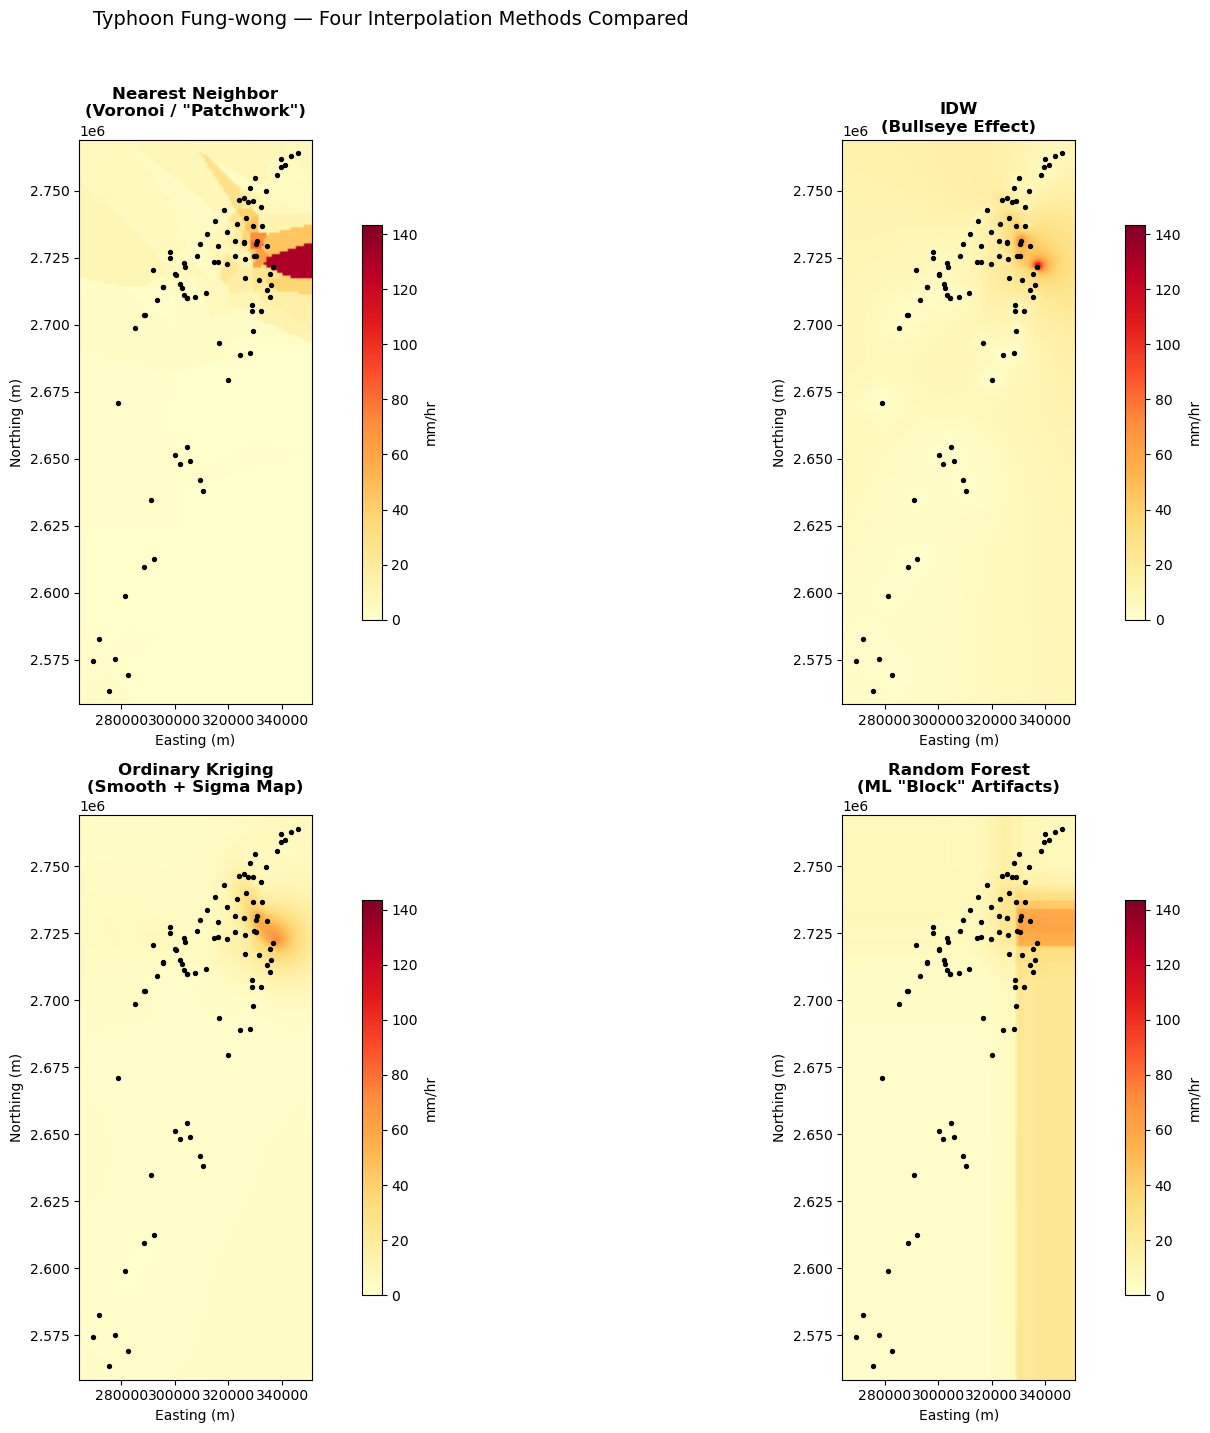

✓ Saved: interpolation_shootout.png


In [12]:
# =========================
# Four interpolation methods side by side
# =========================
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

vmax = max(z) * 1.1

methods = [
    ('Nearest Neighbor\n(Voronoi / "Patchwork")', z_nn),
    ('IDW\n(Bullseye Effect)', z_idw),
    ('Ordinary Kriging\n(Smooth + Sigma Map)', z_kriging),
    ('Random Forest\n(ML "Block" Artifacts)', z_rf),
]

for ax, (title, data) in zip(axes.flatten(), methods):
    im = ax.imshow(
        data,
        extent=[x_min, x_max, y_min, y_max],
        origin='lower',
        cmap='YlOrRd',
        vmin=0,
        vmax=vmax
    )
    ax.scatter(x, y, c='black', s=8, zorder=5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')
    plt.colorbar(im, ax=ax, shrink=0.7, label='mm/hr')

plt.suptitle('Typhoon Fung-wong — Four Interpolation Methods Compared', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('interpolation_shootout.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: interpolation_shootout.png")

### Cell [8]: Kriging vs RF — Direct Comparison

Create a 3-panel comparison: Kriging | Random Forest | Difference Map

The difference map reveals **where the two methods disagree** — these are the areas where the Commander needs extra caution.

In [ ]:
# YOUR CODE HERE:
# 1. Create fig, axes = plt.subplots(1, 3, figsize=(22, 7))
# 2. Left: Kriging (YlOrRd)
# 3. Middle: Random Forest (YlOrRd)
# 4. Right: Difference (Kriging - RF) using RdBu_r colormap
# 5. Save as 'kriging_vs_rf.png'

# diff = z_kriging - z_rf
# ...

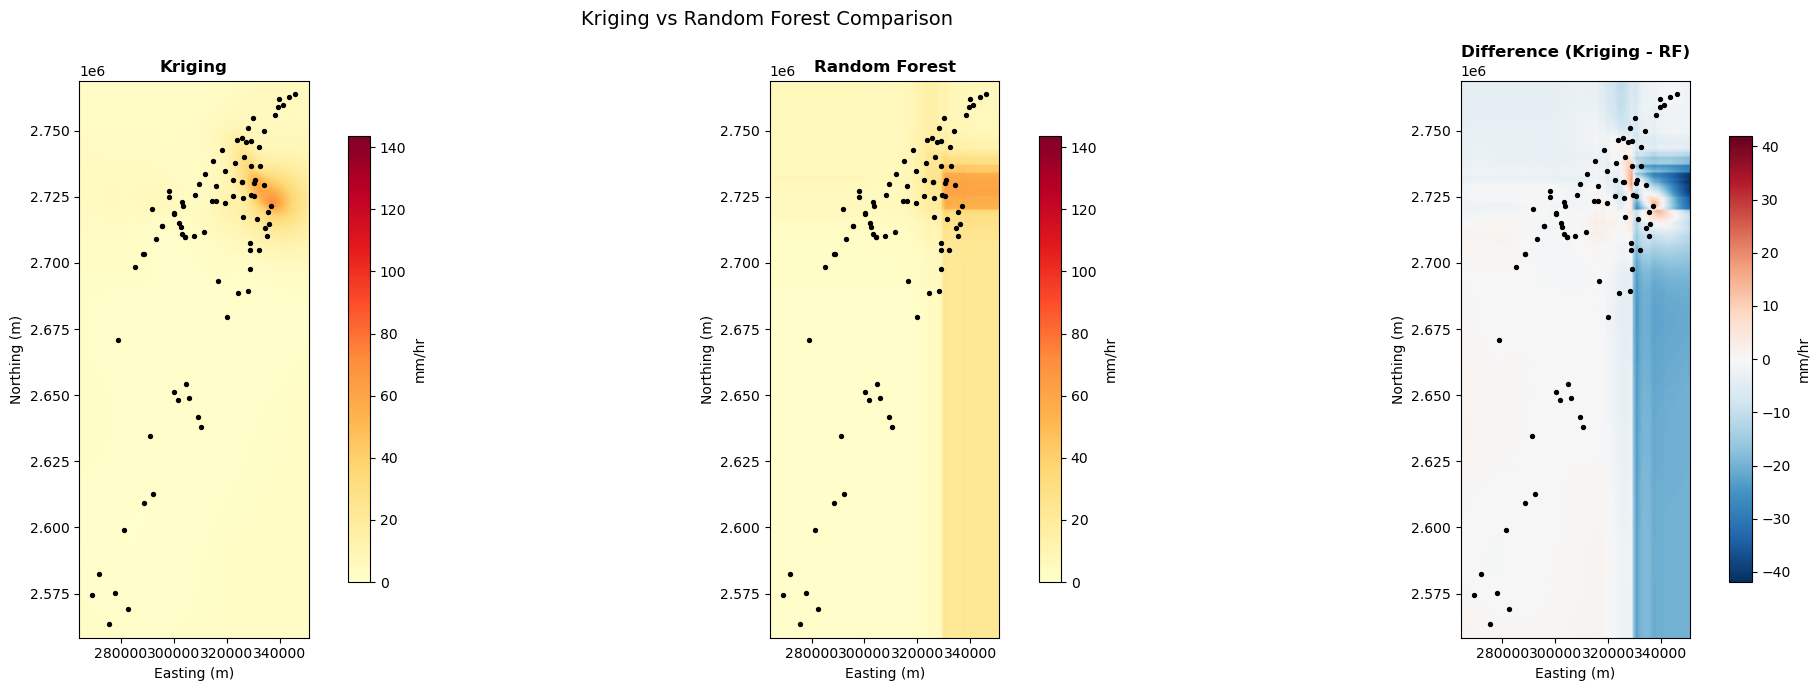

✓ Saved: kriging_vs_rf.png


In [13]:
# =========================
# Kriging vs Random Forest comparison
# =========================
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

vmax = max(z) * 1.1

# 1. Kriging
im1 = axes[0].imshow(
    z_kriging,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    cmap='YlOrRd',
    vmin=0,
    vmax=vmax
)
axes[0].scatter(x, y, c='black', s=8)
axes[0].set_title('Kriging', fontweight='bold')
plt.colorbar(im1, ax=axes[0], shrink=0.8, label='mm/hr')

# 2. Random Forest
im2 = axes[1].imshow(
    z_rf,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    cmap='YlOrRd',
    vmin=0,
    vmax=vmax
)
axes[1].scatter(x, y, c='black', s=8)
axes[1].set_title('Random Forest', fontweight='bold')
plt.colorbar(im2, ax=axes[1], shrink=0.8, label='mm/hr')

# 3. Difference (Kriging - RF)
diff = z_kriging - z_rf

vmax_diff = np.max(np.abs(diff))

im3 = axes[2].imshow(
    diff,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    cmap='RdBu_r',
    vmin=-vmax_diff,
    vmax=vmax_diff
)
axes[2].scatter(x, y, c='black', s=8)
axes[2].set_title('Difference (Kriging - RF)', fontweight='bold')
plt.colorbar(im3, ax=axes[2], shrink=0.8, label='mm/hr')

for ax in axes:
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')

plt.suptitle('Kriging vs Random Forest Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('kriging_vs_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: kriging_vs_rf.png")

### Lab 1 Reflection

**Questions to answer** (write in the cell below):

1. Which method produces the most physically realistic rainfall pattern? Why?
2. Where do Kriging and RF disagree the most? What does this tell you?
3. What "artifacts" do you observe in the NN and RF results?
4. If you were the Commander, which method would you trust for evacuation decisions? Why?

**Your Lab 1 reflection here:**

1.在本實驗中，**Kriging（普通克利金）**所產生的降雨分布最符合物理現實。其原因在於Kriging能夠考慮空間自相關（spatial autocorrelation），使降雨場呈現平滑且連續的變化，較符合實際降雨受地形與氣流影響的特性。此外，Kriging也能避免極端值造成的不合理局部波動，因此在空間解釋性上優於其他方法。

2.Kriging與Random Forest的差異主要出現在高降雨區域與測站密集區附近。在這些區域中，兩者的預測值差異較大，顯示Random Forest可能對極端降雨的空間延伸掌握較不穩定。這反映出Random Forest僅使用座標（x, y）作為特徵，缺乏對地形與氣象機制的理解，因此在空間連續性與物理一致性上不如Kriging。

3.Nearest Neighbor呈現明顯的拼貼狀（patchwork）或Voronoi分區效果，區域邊界非常突兀，缺乏空間連續性。
Random Forest則出現區塊狀（blocky）或條帶狀（grid-like）結構，這是由決策樹分割特徵空間所造成的人工痕跡，導致預測結果在空間上呈現不自然的分段變化。

4.若作為防災決策依據，我會選擇Kriging。因為Kriging提供較為平滑且具有空間一致性的降雨分布，較符合實際降雨機制，並能降低局部極端值造成的誤判風險。此外，Kriging在地理統計上具有理論基礎，結果較具可解釋性，對於決策支援更具可靠性。

---

## ⏸️ Lab 2: Confidence & Uncertainty Diagnosis (30 min)

### Cell [9]: The Sigma Map — Kriging's Unique Weapon (Slide 15)

**Captain's Log**: This is what makes Kriging special. No other method natively provides a confidence map.

- `ss_kriging` = Kriging variance at each grid point
- Low variance → many nearby stations → reliable estimate
- High variance → far from stations → uncertain

**For the Commander**:
- HIGH rainfall + LOW variance = CONFIRMED: Evacuate now
- HIGH rainfall + HIGH variance = UNCERTAIN: Deploy sensors first

In [ ]:
# YOUR CODE HERE:
# Create a 2-panel figure:
# Left: z_kriging with YlOrRd colormap (rainfall estimate)
# Right: ss_kriging with Blues colormap (variance/uncertainty)
# Add station locations on both panels (red dots on variance map)
# Save as 'sigma_map.png'

# fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# # Rainfall estimate
# im1 = axes[0].imshow(z_kriging, extent=[x_min, x_max, y_min, y_max],
#                       origin='lower', cmap='YlOrRd', vmin=0)
# axes[0].scatter(x, y, c='black', s=10, zorder=5)
# axes[0].set_title('Estimated Rainfall (mm/hr)')
# plt.colorbar(im1, ax=axes[0], shrink=0.8, label='mm/hr')

# # Kriging Variance (Sigma Map)
# im2 = axes[1].imshow(ss_kriging, extent=[x_min, x_max, y_min, y_max],
#                       origin='lower', cmap='Blues', vmin=0)
# axes[1].scatter(x, y, c='red', s=10, zorder=5, label='Stations')
# axes[1].set_title('Kriging Sigma Map (Uncertainty)')
# axes[1].legend(loc='upper right')
# plt.colorbar(im2, ax=axes[1], shrink=0.8, label='Variance')

# plt.suptitle('The Honest Report Card: Estimate + Confidence', fontsize=14, y=1.02)
# plt.tight_layout()
# plt.savefig('sigma_map.png', dpi=150, bbox_inches='tight')
# plt.show()

# print(f"Variance range: {np.nanmin(ss_kriging):.1f} - {np.nanmax(ss_kriging):.1f}")

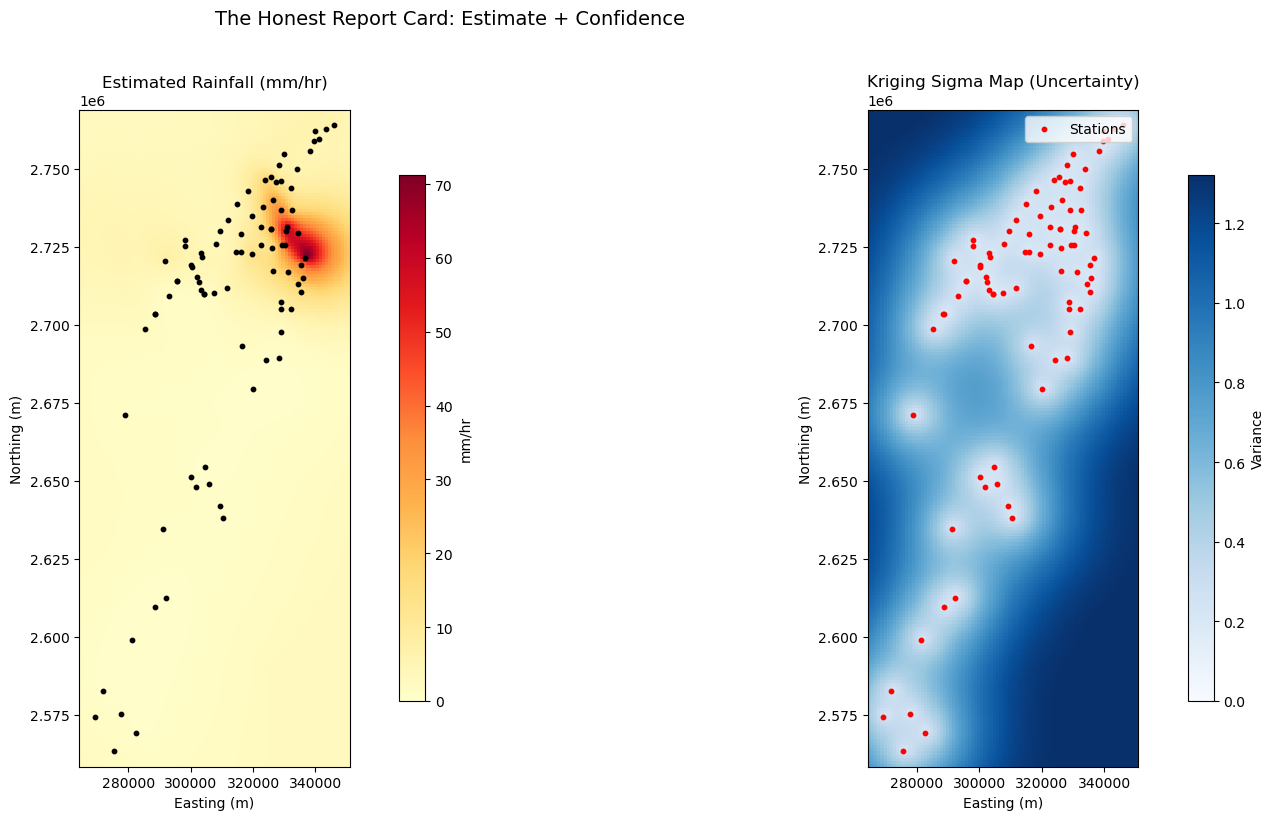

Variance range: 0.172 - 1.320


In [14]:
# =========================
# Sigma Map: estimate + uncertainty
# =========================
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: Kriging rainfall estimate
im1 = axes[0].imshow(
    z_kriging,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    cmap='YlOrRd',
    vmin=0
)
axes[0].scatter(x, y, c='black', s=10, zorder=5)
axes[0].set_title('Estimated Rainfall (mm/hr)')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')
plt.colorbar(im1, ax=axes[0], shrink=0.8, label='mm/hr')

# Right: Kriging variance / uncertainty
im2 = axes[1].imshow(
    ss_kriging,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    cmap='Blues',
    vmin=0
)
axes[1].scatter(x, y, c='red', s=10, zorder=5, label='Stations')
axes[1].set_title('Kriging Sigma Map (Uncertainty)')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')
axes[1].legend(loc='upper right')
plt.colorbar(im2, ax=axes[1], shrink=0.8, label='Variance')

plt.suptitle('The Honest Report Card: Estimate + Confidence', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('sigma_map.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Variance range: {np.nanmin(ss_kriging):.3f} - {np.nanmax(ss_kriging):.3f}")

### Cell [9b]: Nugget Effect — Why Extreme Rain Gets Diluted (Slide 7)

Suao recorded **130.5 mm/hr**, but default Kriging predicts only ~71 mm at 500m away. Why?

**Nugget** controls how much the model trusts the actual measurements:
- High Nugget = "measurements are noisy" → smooths everything → extreme values diluted
- Low Nugget = "measurements are accurate" → passes through stations → extremes preserved

**Task**: Compare Nugget=10% vs Nugget=1% on a zoomed-in map around Suao. Which preserves the extreme rainfall better?

**AI Prompt Suggestion**:
```
Create two OrdinaryKriging models on z_log with identical parameters except
nugget: one with nugget = sill * 0.10, one with nugget = sill * 0.01.
Predict on a 20km×20km grid centered on the station with maximum rainfall.
Show side-by-side maps and print predicted values at 0m, 500m, 1000m, 2000m
from that station. Which Nugget preserves the extreme value better?
```

In [ ]:
# YOUR CODE HERE:
# 1. Find the station with maximum rainfall (suao_idx = np.argmax(z))
# 2. Create two OrdinaryKriging models: nugget = sill*0.10 and sill*0.01
# 3. Predict on a local grid (20km box) around that station
# 4. Plot side-by-side comparison maps
# 5. Predict at specific offsets: 0m, 500m, 1000m, 2000m from the station
# 6. Print comparison table

# suao_idx = np.argmax(z)
# suao_x, suao_y, suao_z = x[suao_idx], y[suao_idx], z[suao_idx]
# print(f"Station with max rainfall: {suao_z:.1f} mm/hr")

# sill_val = float(z_log.var())
# ... create OK with nugget = sill_val * 0.10
# ... create OK with nugget = sill_val * 0.01
# ... compare predictions

# 🔑 Which Nugget setting is better for CWA calibrated stations? Why?

Station with max rainfall: 130.5 mm/hr at (336797, 2721406)


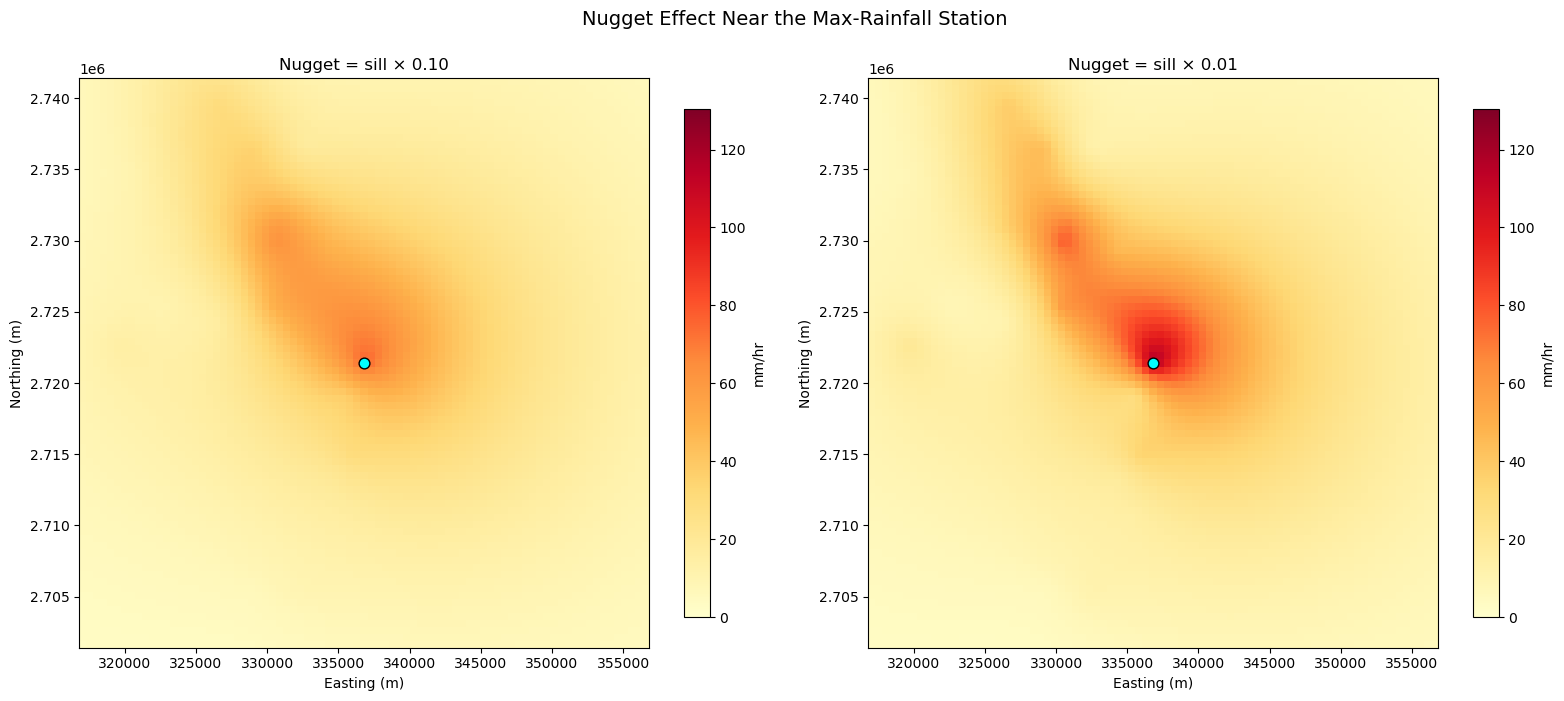


Comparison near the max-rainfall station:
 offset_m  nugget_0.10_mmhr  nugget_0.01_mmhr
        0            130.50            130.50
      500             70.88            107.32
     1000             67.27             98.83
     2000             60.96             85.71

Observed station rainfall: 130.50 mm/hr

🔑 Lower nugget preserves sharp local peaks more strongly.
For well-calibrated CWA rain gauges, a smaller nugget is often more reasonable,
because measurement error is relatively low and we usually trust station observations.


In [16]:
# =========================
# Nugget effect near the max-rainfall station
# =========================

# 1. Find the station with maximum rainfall
suao_idx = np.argmax(z)
suao_x, suao_y, suao_z = x[suao_idx], y[suao_idx], z[suao_idx]
print(f"Station with max rainfall: {suao_z:.1f} mm/hr at ({suao_x:.0f}, {suao_y:.0f})")

# 2. Two OK models with different nugget settings
sill_val = float(z_log.var())
range_val = 50000.0

OK_nugget_10 = OrdinaryKriging(
    x, y, z_log,
    variogram_model='spherical',
    verbose=False,
    enable_plotting=False,
    nlags=15,
    variogram_parameters={
        'sill': sill_val,
        'range': range_val,
        'nugget': sill_val * 0.10
    }
)

OK_nugget_01 = OrdinaryKriging(
    x, y, z_log,
    variogram_model='spherical',
    verbose=False,
    enable_plotting=False,
    nlags=15,
    variogram_parameters={
        'sill': sill_val,
        'range': range_val,
        'nugget': sill_val * 0.01
    }
)

# 3. Local grid: 20 km box around the max station
local_half_size = 20000   # 20 km
local_res = 500           # 500 m

local_x = np.arange(suao_x - local_half_size, suao_x + local_half_size + local_res, local_res)
local_y = np.arange(suao_y - local_half_size, suao_y + local_half_size + local_res, local_res)

z10_log, ss10 = OK_nugget_10.execute('grid', local_x, local_y)
z01_log, ss01 = OK_nugget_01.execute('grid', local_x, local_y)

z10 = np.expm1(z10_log)
z01 = np.expm1(z01_log)

z10[z10 < 0] = 0
z01[z01 < 0] = 0

# 4. Side-by-side maps
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

vmax_local = max(np.nanmax(z10), np.nanmax(z01), suao_z)

im1 = axes[0].imshow(
    z10,
    extent=[local_x.min(), local_x.max(), local_y.min(), local_y.max()],
    origin='lower',
    cmap='YlOrRd',
    vmin=0,
    vmax=vmax_local
)
axes[0].scatter(suao_x, suao_y, c='cyan', s=60, edgecolor='black', zorder=5)
axes[0].set_title('Nugget = sill × 0.10')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')
plt.colorbar(im1, ax=axes[0], shrink=0.8, label='mm/hr')

im2 = axes[1].imshow(
    z01,
    extent=[local_x.min(), local_x.max(), local_y.min(), local_y.max()],
    origin='lower',
    cmap='YlOrRd',
    vmin=0,
    vmax=vmax_local
)
axes[1].scatter(suao_x, suao_y, c='cyan', s=60, edgecolor='black', zorder=5)
axes[1].set_title('Nugget = sill × 0.01')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')
plt.colorbar(im2, ax=axes[1], shrink=0.8, label='mm/hr')

plt.suptitle('Nugget Effect Near the Max-Rainfall Station', fontsize=14)
plt.tight_layout()
plt.show()

# 5. Predict at specific offsets
offsets = [0, 500, 1000, 2000]
rows = []

for d in offsets:
    pred10_log, var10 = OK_nugget_10.execute('points', np.array([suao_x + d]), np.array([suao_y]))
    pred01_log, var01 = OK_nugget_01.execute('points', np.array([suao_x + d]), np.array([suao_y]))

    pred10 = float(np.expm1(pred10_log[0]))
    pred01 = float(np.expm1(pred01_log[0]))

    rows.append({
        'offset_m': d,
        'nugget_0.10_mmhr': pred10,
        'nugget_0.01_mmhr': pred01
    })

compare_df = pd.DataFrame(rows)

# 6. Print comparison table
print("\nComparison near the max-rainfall station:")
print(compare_df.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

print(f"\nObserved station rainfall: {suao_z:.2f} mm/hr")
print("\n🔑 Lower nugget preserves sharp local peaks more strongly.")
print("For well-calibrated CWA rain gauges, a smaller nugget is often more reasonable,")
print("because measurement error is relatively low and we usually trust station observations.")

### Cell [10]: Export to GeoTIFF (Slide 16)

⚠️ **Flip warning**: `z_kriging` row 0 = south (numpy convention). GeoTIFF row 0 = north. Use `np.flipud()` to fix.

**AI Prompt Suggestion**:
```
Save 2D numpy arrays as GeoTIFF using rasterio. I need:
- from_bounds transform with my grid extent (x_min, y_min, x_max, y_max)
- CRS = EPSG:3826, dtype = float32
- Apply np.flipud() before writing
- Save kriging_rainfall.tif, kriging_variance.tif, and rf_rainfall.tif
```

In [ ]:
import rasterio
from rasterio.transform import from_bounds

# YOUR CODE HERE:
# 1. Compute rasterio transform using from_bounds
# 2. Write a helper function save_geotiff(data, filename)
# 3. Save kriging_rainfall.tif, kriging_variance.tif, rf_rainfall.tif
# Remember: np.flipud() before writing!

# transform = from_bounds(x_min, y_min, x_max, y_max,
#                         width=z_kriging.shape[1], height=z_kriging.shape[0])

# def save_geotiff(data, filename, crs='EPSG:3826'):
#     data_flipped = np.flipud(data).astype(np.float32)
#     with rasterio.open(filename, 'w', driver='GTiff',
#         height=data_flipped.shape[0], width=data_flipped.shape[1],
#         count=1, dtype='float32', crs=crs, transform=transform, nodata=-9999
#     ) as dst:
#         dst.write(data_flipped, 1)
#     print(f"✓ Saved {filename}")

# save_geotiff(z_kriging, 'kriging_rainfall.tif')
# save_geotiff(ss_kriging, 'kriging_variance.tif')
# save_geotiff(z_rf, 'rf_rainfall.tif')

In [17]:
import rasterio
from rasterio.transform import from_bounds

# =========================
# 1. 建立 transform（空間定位關鍵）
# =========================
transform = from_bounds(
    x_min, y_min, x_max, y_max,
    width=z_kriging.shape[1],
    height=z_kriging.shape[0]
)

# =========================
# 2. 寫一個通用輸出函數
# =========================
def save_geotiff(data, filename, crs='EPSG:3826'):
    # ⚠️ matplotlib / numpy 與 raster 座標方向不同 → 要翻轉
    data_flipped = np.flipud(data).astype(np.float32)

    # 處理 NaN → nodata
    data_flipped[np.isnan(data_flipped)] = -9999

    with rasterio.open(
        filename,
        'w',
        driver='GTiff',
        height=data_flipped.shape[0],
        width=data_flipped.shape[1],
        count=1,
        dtype='float32',
        crs=crs,
        transform=transform,
        nodata=-9999
    ) as dst:
        dst.write(data_flipped, 1)

    print(f"✓ Saved {filename}")

# =========================
# 3. 輸出三個圖層
# =========================
save_geotiff(z_kriging, 'kriging_rainfall.tif')
save_geotiff(ss_kriging, 'kriging_variance.tif')
save_geotiff(z_rf, 'rf_rainfall.tif')

✓ Saved kriging_rainfall.tif
✓ Saved kriging_variance.tif
✓ Saved rf_rainfall.tif


### Cell [11]: Zonal Statistics — Township Decision Table

Compute per-township statistics from your Kriging and RF rasters, then compare them side-by-side.

**Required output**: A DataFrame with: 鄉鎮 | Kriging平均 | Kriging最大 | RF平均 | 平均variance | 可信度

In [ ]:
from rasterstats import zonal_stats

# YOUR CODE HERE:
# 1. Load township boundaries (TGOS shapefile)
# 2. Filter to 花蓮縣 + 宜蘭縣, convert to EPSG:3826
# 3. Run zonal_stats on kriging_rainfall.tif, kriging_variance.tif, rf_rainfall.tif
# 4. Create summary DataFrame with columns:
#    鄉鎮, 縣市, Kriging平均, Kriging最大, RF平均, 平均variance
# 5. Add 可信度 column:
#    HIGH: variance < 33rd percentile
#    MEDIUM: 33rd-66th percentile
#    LOW: > 66th percentile

# Note: If you don't have the township shapefile, skip this cell
# and describe what the expected output would be in the markdown below.

# try:
#     towns = gpd.read_file('path/to/TOWN_MOI.shp')
#     study_towns = towns[towns['COUNTYNAME'].isin(['花蓮縣', '宜蘭縣'])].copy()
#     study_towns = study_towns.to_crs(epsg=3826)
#     ... (compute zonal stats and create summary table)
# except Exception as e:
#     print(f"Township shapefile not found: {e}")

In [18]:
from rasterstats import zonal_stats
import os
import glob

# =========================
# Zonal Statistics: Township decision table
# =========================

try:
    # 1. Try to locate township shapefile automatically
    candidate_paths = [
        "data/TOWN_MOI_1140318.shp",
        "data/TOWN_MOI.shp",
        "data/township/TOWN_MOI.shp",
        "data/tgos/TOWN_MOI.shp",
        "data/鄉(鎮、市、區)界線1140318/TOWN_MOI_1140318.shp",
        "data/鄉(鎮、市、區)界線1140318/TOWN_MOI.shp",
    ]

    shp_path = None

    for p in candidate_paths:
        if os.path.exists(p):
            shp_path = p
            break

    # if not found, search recursively
    if shp_path is None:
        shp_matches = glob.glob("**/*.shp", recursive=True)
        for p in shp_matches:
            name = os.path.basename(p).lower()
            if "town" in name or "tgos" in name or "moi" in name:
                shp_path = p
                break

    if shp_path is None:
        raise FileNotFoundError("找不到 township shapefile (.shp)")

    print(f"Using shapefile: {shp_path}")

    # 2. Load township boundaries
    towns = gpd.read_file(shp_path)

    # 3. Inspect likely field names
    print("Columns:", list(towns.columns))

    # Try to infer county / town name fields
    county_col = None
    town_col = None

    for c in towns.columns:
        c_upper = str(c).upper()
        if county_col is None and c_upper in ["COUNTYNAME", "COUNTY_NAM", "COUNTY", "縣市"]:
            county_col = c
        if town_col is None and c_upper in ["TOWNNAME", "TOWN_NAM", "TOWN", "鄉鎮市區", "TOWNSHIP"]:
            town_col = c

    # fallback guesses
    if county_col is None:
        for c in towns.columns:
            if "COUNTY" in str(c).upper() or "縣" in str(c):
                county_col = c
                break

    if town_col is None:
        for c in towns.columns:
            cu = str(c).upper()
            if "TOWN" in cu or "VILL" in cu or "鄉" in str(c) or "鎮" in str(c) or "市" in str(c) or "區" in str(c):
                town_col = c
                break

    if county_col is None or town_col is None:
        raise ValueError(f"無法辨識縣市/鄉鎮欄位。county_col={county_col}, town_col={town_col}")

    print(f"County column: {county_col}")
    print(f"Town column: {town_col}")

    # 4. Filter to 宜蘭縣 + 花蓮縣 and project to EPSG:3826
    study_towns = towns[towns[county_col].isin(['花蓮縣', '宜蘭縣'])].copy()
    study_towns = study_towns.to_crs(epsg=3826)

    print(f"Selected townships: {len(study_towns)}")

    # 5. Run zonal statistics
    kriging_stats = zonal_stats(
        study_towns,
        'kriging_rainfall.tif',
        stats=['mean', 'max'],
        nodata=-9999
    )

    variance_stats = zonal_stats(
        study_towns,
        'kriging_variance.tif',
        stats=['mean'],
        nodata=-9999
    )

    rf_stats = zonal_stats(
        study_towns,
        'rf_rainfall.tif',
        stats=['mean'],
        nodata=-9999
    )

    # 6. Create summary table
    summary_df = pd.DataFrame({
        '鄉鎮': study_towns[town_col].values,
        '縣市': study_towns[county_col].values,
        'Kriging平均': [s.get('mean', np.nan) for s in kriging_stats],
        'Kriging最大': [s.get('max', np.nan) for s in kriging_stats],
        'RF平均': [s.get('mean', np.nan) for s in rf_stats],
        '平均variance': [s.get('mean', np.nan) for s in variance_stats],
    })

    # 7. Add confidence class by variance quantiles
    q33 = summary_df['平均variance'].quantile(0.33)
    q66 = summary_df['平均variance'].quantile(0.66)

    def classify_confidence(v):
        if pd.isna(v):
            return np.nan
        elif v < q33:
            return 'HIGH'
        elif v < q66:
            return 'MEDIUM'
        else:
            return 'LOW'

    summary_df['可信度'] = summary_df['平均variance'].apply(classify_confidence)

    # 8. Sort for decision support
    summary_df = summary_df.sort_values(
        by=['Kriging平均', 'Kriging最大'],
        ascending=False
    ).reset_index(drop=True)

    # Optional: round values
    for col in ['Kriging平均', 'Kriging最大', 'RF平均', '平均variance']:
        summary_df[col] = summary_df[col].round(2)

    print("\n=== Township Decision Table ===")
    print(summary_df.head(10).to_string(index=False))

except Exception as e:
    summary_df = None
    print(f"Township shapefile not found or failed to process: {e}")
    print("Skip this cell and explain in markdown what the expected output would be.")

Using shapefile: data/鄉(鎮、市、區)界線1140318/TOWN_MOI_1140318.shp
Columns: ['TOWNID', 'TOWNCODE', 'COUNTYNAME', 'TOWNNAME', 'TOWNENG', 'COUNTYID', 'COUNTYCODE', 'geometry']
County column: COUNTYNAME
Town column: TOWNNAME
Selected townships: 25

=== Township Decision Table ===
 鄉鎮  縣市  Kriging平均  Kriging最大  RF平均  平均variance    可信度
五結鄉 宜蘭縣      46.20      60.17 51.66        0.23   HIGH
羅東鎮 宜蘭縣      38.75      57.86 31.32        0.21   HIGH
蘇澳鎮 宜蘭縣      37.08      71.19 39.19        0.24   HIGH
冬山鄉 宜蘭縣      28.31      59.73 32.81        0.22   HIGH
宜蘭市 宜蘭縣      28.19      35.34 23.94        0.23   HIGH
壯圍鄉 宜蘭縣      23.58      38.92 31.80        0.23   HIGH
礁溪鄉 宜蘭縣      13.36      23.58 14.97        0.24   HIGH
三星鄉 宜蘭縣       9.41      31.84 11.04        0.24   HIGH
員山鄉 宜蘭縣       8.69      24.49 10.67        0.26 MEDIUM
頭城鎮 宜蘭縣       5.77       8.68  9.14        0.25 MEDIUM


### Cell [12]: Thinking Challenge — Why Can't ML Give You a Sigma Map?

**Discussion Questions** (answer in the cell below):

1. Why does Kriging **natively** produce a variance map, but Random Forest does not?
2. Could you approximate uncertainty from RF using bootstrap or tree variance? What are the limitations?
3. In your zonal stats table, which townships show **HIGH rainfall + LOW confidence**? What should the Commander do about those?

**Your Lab 2 reflection here:**

1. Kriging 是基於空間統計理論（geostatistics），其核心為變異數函數（variogram），在進行空間插值時，同時估計：

預測值（mean）
預測不確定性（variance）

因此，每一個預測點都會伴隨一個理論推導出的 variance，反映該位置與周圍測站距離及空間結構的不確定性。

相對地，Random Forest 屬於機器學習方法，其目標是最小化預測誤差，並沒有內建空間統計假設或誤差結構模型，因此：只能輸出預測值，無法直接提供具有空間意義的 variance map

2. 可以透過以下方式近似：

bootstrap（重抽樣）
不同 decision trees 的預測變異（tree variance）

但其限制包括：

-不具空間結構意義無法反映距離、測站密度等空間因素
-無法對應到 variogram不確定度沒有物理或統計上的空間解釋
-可能低估或高估不確定度因為 RF 的變異來自模型結構，而非資料空間分布

3. 從 zonal statistics 結果來看：

高降雨區（如：五結鄉、羅東鎮、蘇澳鎮等）
多屬 HIGH 信度（variance 低）

👉 本案例中「高雨量 + 低可信度」的情況並不明顯

但若實務上出現此類區域（高 rainfall + HIGH variance），代表：

-該區降雨預測高，但不確定性也高
-通常發生於測站稀疏區或邊界區域

### Cell [13]: (Bonus) AI Advisor Consultation

Ask an AI model (Gemini, ChatGPT, or Claude):

> 「在花蓮山區，測站密度約 1 站 / 50 km²。我用 Kriging 和 Random Forest 分別做了降雨內插，結果在山區差異很大。Kriging 的 variance 在山區也很高。請問：(1) 我應該信哪個結果？(2) 如何改善山區的預測品質？」

Paste the AI's response below and write your own commentary.

**AI Response:**

在花蓮山區這種測站稀疏（約 1 站 / 50 km²）且地形劇烈起伏的區域，若 Kriging 與 Random Forest 的內插結果差異很大，而且 Kriging 的 variance 也偏高，代表目前資料條件下，任何單一模型的結果都不宜被過度信任。此時重點不是問「哪一個模型絕對正確」，而是判斷哪一個模型在目前資訊下較可解釋、較可防災使用。

(1) 應該信哪個結果？

若以目前條件來看，我會優先參考 Kriging，但不會單獨依賴它。原因如下：

Kriging 至少誠實地告訴你它在哪裡不確定
山區 variance 很高，表示模型自己也承認該區預測信心不足。這對防災很重要，因為決策者需要知道「哪裡不可靠」。
Random Forest 在只有座標特徵時，容易出現不自然的區塊狀預測
若 RF 只用 x、y 當特徵，它學到的多半只是座標切分，而不是山區真實降雨機制，因此雖然結果有時看起來比較銳利，但不一定更可信。
山區降雨受地形強烈控制，單靠空間鄰近不一定足夠
Kriging 的問題是測站太少時會高不確定；RF 的問題是若缺乏地形與氣象因子，就只是另一種數學擬合。
所以目前比較合理的做法是：
把 Kriging 當作主要參考圖層
把 variance 當作風險提醒圖層
把 RF 當作輔助對照

👉 換句話說：
在高 variance 山區，不應問「信哪一張圖」，而應問「哪裡兩種模型都不穩、需要更保守決策」。

(2) 如何改善山區的預測品質？

要改善山區預測，關鍵不在於只換模型，而在於補足控制山區降雨的資訊。可從以下幾方面著手：

1. 增加觀測資料密度
增設雨量站
納入臨時觀測站或民間感測資料
結合雷達降雨估計產品

這是最直接的方法，因為山區 variance 高往往就是測站太稀疏。

2. 在 Random Forest 中加入地形與環境特徵

可加入：

高程（elevation）
坡度（slope）
坡向（aspect）
與海岸距離
迎風 / 背風指標
地形粗糙度
土地覆蓋

這樣 RF 才有可能學到山區降雨與地形的真實關聯，而不只是座標分割。

3. 使用 regression kriging / hybrid model

先用 RF 或線性模型解釋：

地形
氣象
環境因子

再用 Kriging 對殘差做空間內插。
這樣能兼顧：

RF 對複雜非線性的表現
Kriging 對空間自相關與不確定度的處理
4. 改善 variogram 與 nugget 設定

若山區降雨變化劇烈，可重新檢查：

variogram model 類型
range
nugget 大小
是否分區建模

避免用過度平滑的 variogram 將山區極端值稀釋掉。

5. 區分「預測值」與「決策值」

在高不確定區，防災決策不應只看 mean rainfall，還要同時看：

variance / confidence
最壞情境
鄰近鄉鎮觀測趨勢
現地回報

也就是說，山區高不確定度區域應採取保守決策，而不是只取模型平均值。

**My Commentary:**

我認為上述 AI 回覆是合理的，尤其是它沒有直接說「Kriging 一定比較準」或「RF 一定比較先進」，而是指出在測站稀疏且 Kriging variance 又高的情況下，單一模型都不應被絕對相信，這點很重要。

---

## ARIA Evolution Recap

| Version | Week | Capability | Key Question |
|---------|------|-----------|---------------|
| v1.0 | W3 | River buffer + shelters | How close to the river? |
| v2.0 | W4 | + DEM terrain analysis | How steep is the terrain? |
| v3.0 | W5 | + Real-time rainfall stations | How much rain RIGHT NOW? |
| **v3.5** | **W6** | **+ Kriging & ML interpolation** | **What about areas with NO station? How confident are we?** |
| v4.0 | Final Project | Your extension! | Your question! |

---

*"Interpolation is not just filling space; it is predicting risk where sensors cannot reach."*